**DESCRIPCIÓN**

Esta notebook lee los archivos de flujo (12 valores por canal combustible, valor central por cada elemento) y se generan la base de datos para los cálculos de macaco y del modelo de diámetro exterior.

In [3]:
import pandas as pd
import os

**1º PARTE**

Se genera 1 archivo por cada canal para el pressure tube y para el calandria tube. Cada archivo contiene el valor de flujo correspondiente con la posición axial de cada elemento combustible, adicionalmente en ambos extremos se establece flujo nulo.

Esta base de datos se usa para el modelo de macaco.

In [3]:

def generate_flux_data(inputfile, output_dir):
    # Crear la carpeta de salida si no existe
    os.makedirs(output_dir, exist_ok=True)
    
    # Cargar el CSV
    df = pd.read_csv(inputfile)
    
    ntrozos = df.shape[1] - 1  # Número de trozos, asumiendo que 'Canal' es la primera columna
    
    for index, row in df.iterrows():
        canal = row['Canal']
        
        # Crear los datos
        coord_rel = [0] + [(i-0.5) / ntrozos for i in range(1, ntrozos + 1)] + [1]
        flux_1mev = [0] + [row[f'Trozo_{i}'] for i in range(1, ntrozos + 1)] + [0]
        
        # Crear DataFrame
        df_output = pd.DataFrame({
            'coord_rel': coord_rel,
            'flux_1mev': flux_1mev
        })
        
        # Definir ruta completa
        filename = os.path.join(output_dir, f"{canal}.flx")
        
        # Guardar en archivo
        df_output.to_csv(filename, index=False, sep='\t', header=False)
    

In [4]:
# For pressure tubes
inputfile = '../data/flux/pt_flux_1MeV.csv'
output_dir = '../data/flux/pressure_tubes/'

generate_flux_data(inputfile, output_dir)

In [5]:
# For calandria tubes
inputfile = '../data/flux/ct_flux_1MeV.csv'
output_dir = '../data/flux/calandria_tubes/'

generate_flux_data(inputfile, output_dir)

**2º PARTE**

Se genera 1 archivo por cada canal para el pressure tube y para el calandria tube. Cada archivo contiene el valor de flujo a lo largo de la coordenada axial. Con los valores en el centro de cada elemento combustible se fitea un modelo compuesto por la superposición de una onda larga sinusoidal con máximo en centro y nula en los extremos, más una variación local dada por una semi-onda de longitud 1/12 (número de elementos combustibles) aplanada. Se busca generar una distribución de flujo realista con caías entre elementos combustibles.

Por cada canal, se ajusta la expresión del modelo propuesto y se guardan datos para 1200 puntos por tubo.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# === MODELO: 
# Onda larga: sin(πx) → cero en bordes, máximo en x=0.5
# Onda corta: semi-onda de longitud 1/12 → |sin(12πx)| → 6 semi-oscilaciones
# → Máximos en x = 0.5/12, 1.5/12, 2.5/12, ..., 5.5/12 (6 puntos)
# → Mínimos = 0 en x = 0, 1/12, 2/12, ..., 1

class FluxCurve:
    def __init__(self, kparam=5, nbundles=12):
        self.kparam = kparam
        self.nbundles = nbundles
        self.A = None
        self.B = None
        self.fitted = False
        
    def _model(self, x, A, B):
        """Physical model: global cosine-like + local bundle oscillations"""
        global_func = A * np.sin(np.pi * x)
        local_func = B * (np.abs(np.sin(self.nbundles * np.pi * x)))**(1/self.kparam)
        return global_func + local_func
    
    def fit(self, xdata, ydata):
        """
        Fit the model to data.
        p0: initial guess [A0, B0]
        bounds: ((A_min, B_min), (A_max, B_max))
        """
        
        p0 = np.max(ydata) * np.array([1.03 , 0.4])
        bounds = (
        [.9 * p0[0], 0.2 * p0[1]],   # lower
        [1.5 * p0[0], 1.1 * p0[1]]    # upper
    )
        
        try: 
            best_params, _ = curve_fit(self._model, xdata, ydata, p0 = p0, bounds = bounds, maxfev = 5000)
            self.A, self.B = best_params
            self.fitted = True
            return self.A, self.B
        except RuntimeError as e:
            warnings.warn(f"Fit failed: {e}")
            self.fitted = False
            return None, None

    def predict(self, xdata):
        """Predict flux at given points"""
        if not self.fitted:
            raise RuntimeError("Model must be fitted first using .fit()")
        xdata = np.asarray(xdata)
        return self._model(xdata, self.A, self.B)
    
    def plot(self, xdata, ydata=None, channel = None, show_data=True, ax=None):
        """Plot data and fitted model"""
        if not self.fitted:
            raise RuntimeError("Model must be fitted first using .fit()")

        if ax is None:
            fig, ax = plt.subplots(figsize=(8, 5))
        
        x_fine = np.linspace(0, 1, 1000)
        y_fine = self.predict(x_fine)

        # Plot fitted curve
        ax.plot(x_fine, y_fine, 'b-', linewidth=3.5, label=f'Fitted model')

        # Plot data if provided
        if show_data and ydata is not None:
            xdata = np.asarray(xdata)
            ydata = np.asarray(ydata)
            ax.scatter(xdata, ydata, color='red', s=100, label='Flux data', 
                      zorder=6, edgecolors='black', linewidth=1.2)

        # Formatting
        ax.set_title(f'Fast Neutron Flux: Data vs Fitted Model - Channel: {channel}', fontsize=16, pad=15)
        ax.set_xlabel('Relative Axial Position', fontsize=13)
        ax.set_ylabel('Fast Neutron Flux [n/cm²/s]', fontsize=13)
        ax.legend(fontsize=11, loc='upper right')
        ax.grid(True, alpha=0.3)
        ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

        if ax is None:
            plt.tight_layout()
            plt.show()
        else:
            return ax

In [16]:
def generate_extended_flux_data(inputfile, output_dir):
    # Crear la carpeta de salida si no existe
    os.makedirs(output_dir, exist_ok=True)
    
    # Cargar el CSV
    df = pd.read_csv(inputfile)
    
    ntrozos = df.shape[1] - 1  # Número de trozos, asumiendo que 'Canal' es la primera columna
    
    nplots = 5
    nchannels = 360
    
    channels_to_plot = np.random.choice(nchannels, size=nplots, replace=False)
    
    for index, row in df.iterrows():
        canal = row['Canal']
        
        # Crear los datos para fitear
        coord_rel = [0] + [(i-0.5) / ntrozos for i in range(1, ntrozos + 1)] + [1]
        flux_1mev = [0] + [row[f'Trozo_{i}'] for i in range(1, ntrozos + 1)] + [0]
        
        model = FluxCurve()
        model.fit(np.array(coord_rel), np.array(flux_1mev))
        
        ext_coord_rel = np.linspace(0, 1, 1200)
        ext_flux_1mev = model.predict(ext_coord_rel)

        # Crear DataFrame
        df_output = pd.DataFrame({
            'coord_rel': ext_coord_rel,
            'flux_1mev': ext_flux_1mev
        })
        
        # Definir ruta completa
        filename = os.path.join(output_dir, f"{canal}.flx")
        
        # Guardar en archivo
        df_output.to_csv(filename, index=False, sep='\t', header=False)
        
        if index in channels_to_plot:
            model.plot(coord_rel, flux_1mev, channel = canal)

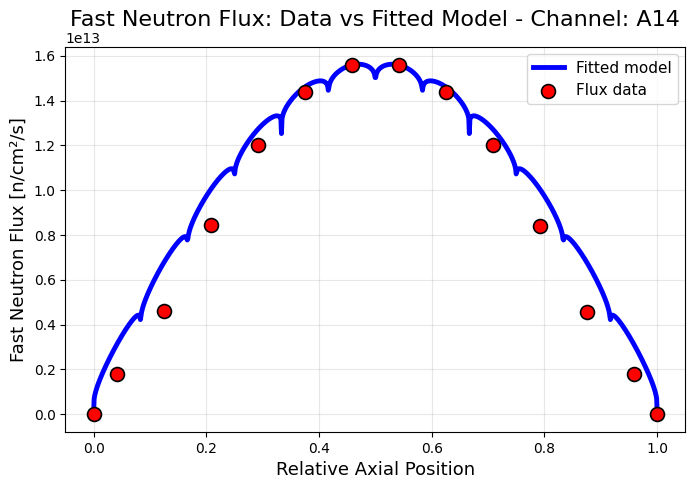

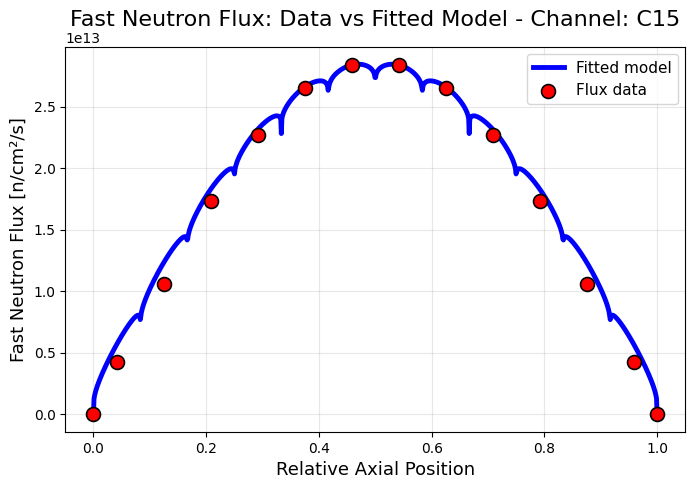

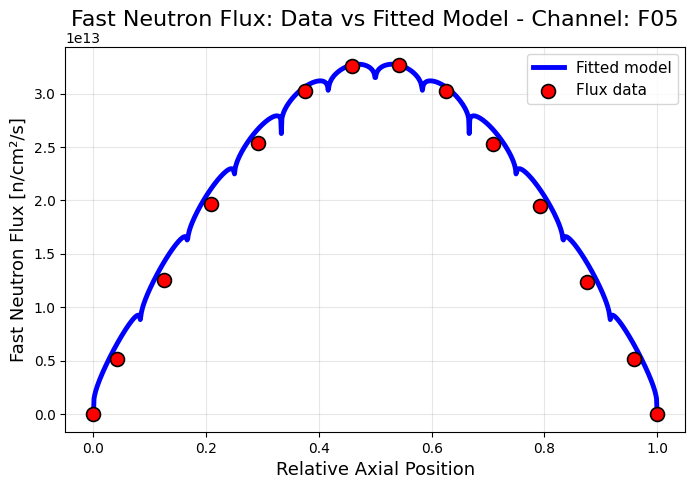

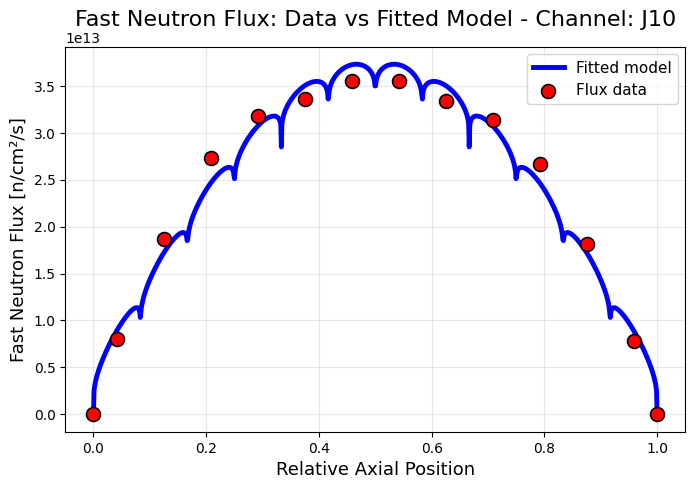

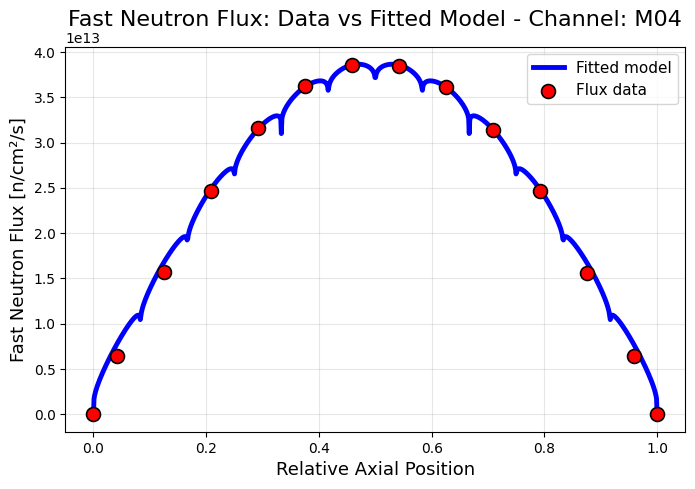

In [17]:
# For pressure tubes
inputfile = '../data/flux/pt_flux_1MeV.csv'
output_dir = '../data/flux/pressure_tubes_extended/'

generate_extended_flux_data(inputfile, output_dir)

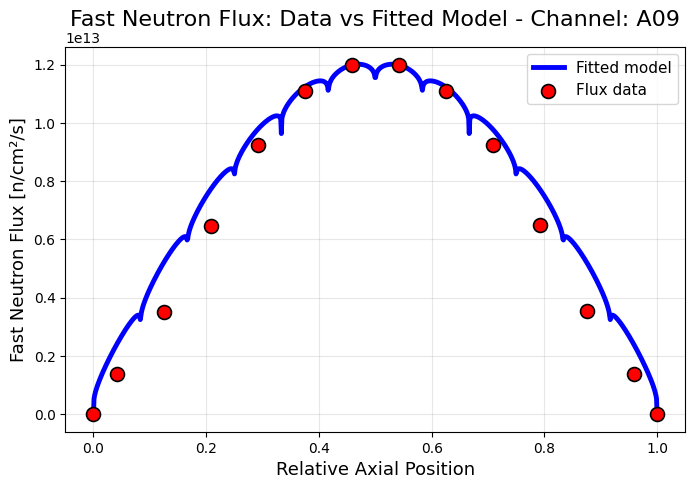

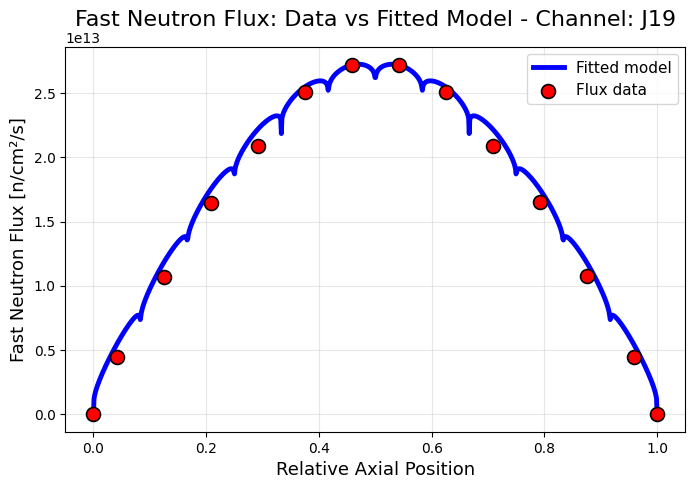

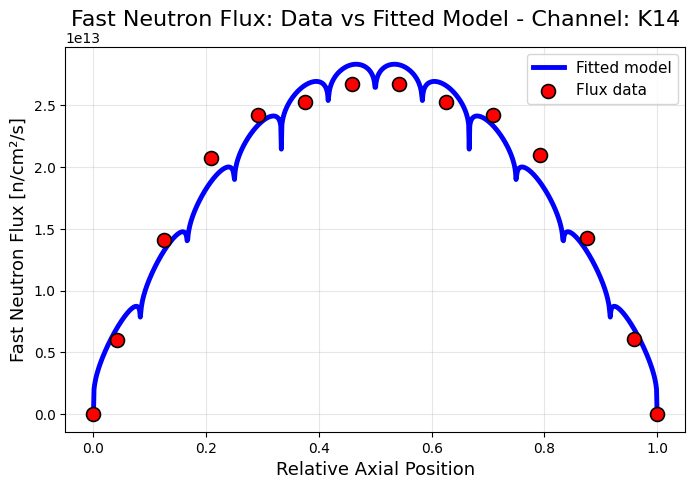

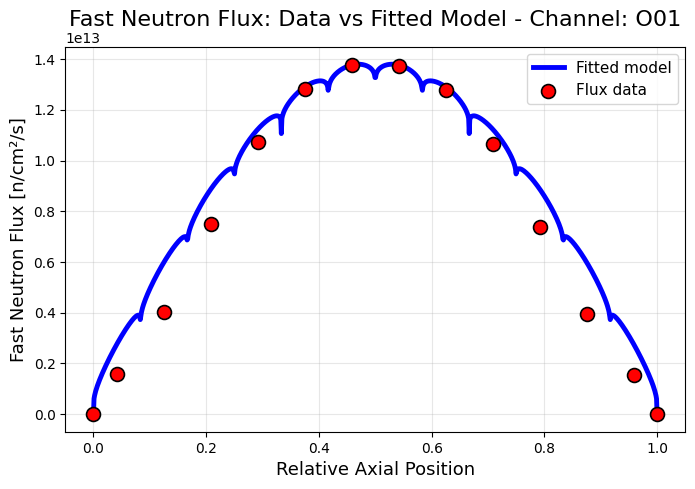

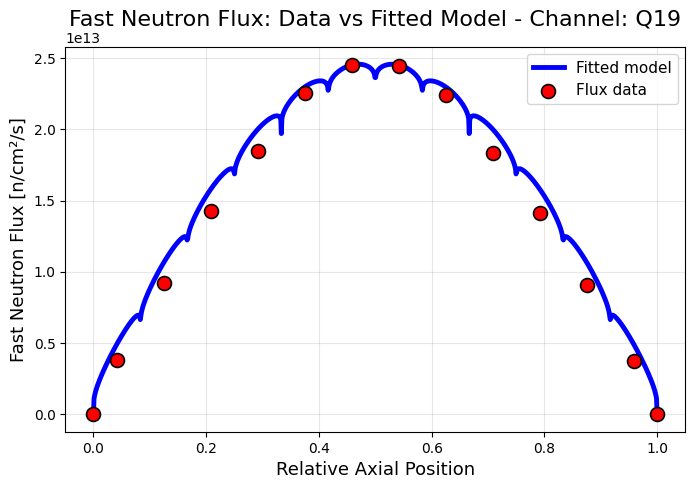

In [18]:
# For calandria tubes
inputfile = '../data/flux/ct_flux_1MeV.csv'
output_dir = '../data/flux/calandria_tubes_extended/'

generate_extended_flux_data(inputfile, output_dir)